# 02 - Train Classifier (Stage 2)
Notebook pentru experimentele B1/B2/B3 (classificare material: glass, metal, other, paper, plastic).

In [1]:
from pathlib import Path
import torch
from ultralytics import YOLO

REPO_ROOT = Path('../..').resolve()
print('REPO_ROOT:', REPO_ROOT)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

REPO_ROOT: D:\TrashDetectionSystem
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# Config B2 (TrashNet)
DATA_DIR = str(REPO_ROOT / 'datasets' / 'trashnet_cls')
BASE_MODEL = 'yolov8n-cls.pt'
EPOCHS = 50
IMGSZ = 224
BATCH = 32
WORKERS = 0
PATIENCE = 20
SEED = 42
DEVICE = '0'
RUN_NAME = 'parks-cls-B2'
PROJECT = str(REPO_ROOT / 'runs' / 'classify')

print(DATA_DIR)

D:\TrashDetectionSystem\datasets\trashnet_cls


In [3]:
data_root = Path(DATA_DIR)
assert data_root.exists(), f'Missing data dir: {data_root}'
for split in ('train', 'val', 'test'):
    split_dir = data_root / split
    n = sum(1 for p in split_dir.rglob('*') if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'})
    print(split, n)

train 2019
val 251
test 257


In [4]:
model = YOLO(BASE_MODEL)
results = model.train(
    data=DATA_DIR, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, workers=WORKERS,
    patience=PATIENCE, project=PROJECT, name=RUN_NAME, seed=SEED, device=DEVICE
)
save_dir = Path(getattr(results, 'save_dir', PROJECT))
print('save_dir:', save_dir)
print('best:', save_dir / 'weights' / 'best.pt')

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\trashnet_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1

In [5]:
vr = model.val(data=DATA_DIR, split='val', imgsz=IMGSZ, batch=BATCH,
               device=DEVICE, workers=WORKERS)
print(vr)


Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,441,285 parameters, 0 gradients, 3.3 GFLOPs
train: D:\TrashDetectionSystem\datasets\trashnet_cls\train... found 2019 images in 5 classes  
val: D:\TrashDetectionSystem\datasets\trashnet_cls\val... found 251 images in 5 classes  
test: D:\TrashDetectionSystem\datasets\trashnet_cls\test... found 257 images in 5 classes  
val: Fast image access  (ping: 0.00.0 ms, read: 72.623.2 MB/s, size: 11.4 KB)
val: Scanning D:\TrashDetectionSystem\datasets\trashnet_cls\val... 251 images, 0 corrupt: 100% ━━━━━━━━━━━━ 251/251  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 5.1it/s 1.6s0.2s
                   all      0.952          1
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to D:\TrashDetectionSystem\runs\classify\val2
ultralytics.utils.metrics.ClassifyMetrics object with attri

# 02 — Antrenare Clasificator (Stage 2)

Antrenează un **clasificator YOLOv8 pe 5 clase de materiale**: `glass | metal | other | paper | plastic`.

## Experimente planificate (conform EXPERIMENT_PLAN.md)

| ID | Model       | imgsz | epochs | Dataset                 | Scop                          |
|----|-------------|-------|--------|-------------------------|-------------------------------|
| B1 | yolov8n-cls | 224   | 50     | parks_cls (crops only)  | Baseline domain-specific      |
| B2 | yolov8n-cls | 224   | 50     | trashnet_cls (public)   | Baseline date publice         |
| B3 | yolov8n-cls | 224   | 80     | mixed_cls (parks+NET)   | Cel mai bun rezultat așteptat |

**Pre-condiție**: Ai rulat `02_classification_data.ipynb` (split + merge date).

In [6]:
import sys
from pathlib import Path

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ultralytics import YOLO

print(f"Rădăcina proiectului: {REPO_ROOT}")

Rădăcina proiectului: D:\TrashDetectionSystem


In [7]:
# ── CONFIG — schimbă pentru fiecare experiment ────────────────────────────────

# Dataset (alege unul)
# DATA_DIR   = str(REPO_ROOT / "datasets" / "parks_cls")      # B1 — crops parks (gol deocamdată)
DATA_DIR   = str(REPO_ROOT / "datasets" / "trashnet_cls")   # B2 — TrashNet (date disponibile)
# DATA_DIR = str(REPO_ROOT / "datasets" / "mixed_cls")      # B3 — mixed

# Model de bază
BASE_MODEL  = "yolov8n-cls.pt"

# Hiperparametri
EPOCHS      = 50       # B1/B2: 50 | B3: 80
IMGSZ       = 224
BATCH       = 32
PATIENCE    = 20
WORKERS     = 0        # 0 = stabil pe Windows
SEED        = 42
DEVICE      = "0"      # "0" = GPU RTX 3050 | "cpu" | None=auto
CACHE       = False
RESUME      = False

# Identificare run
RUN_NAME    = "parks-cls-B2"   # B1=parks_cls, B2=trashnet, B3=mixed
PROJECT     = None
VAL_SPLIT   = "val"

print(f"Model: {BASE_MODEL}  |  Date: {Path(DATA_DIR).name}")
print(f"Epochs: {EPOCHS}  |  imgsz: {IMGSZ}  |  batch: {BATCH}")
print(f"Run: {RUN_NAME}  |  Device: {DEVICE}")


Model: yolov8n-cls.pt  |  Date: trashnet_cls
Epochs: 50  |  imgsz: 224  |  batch: 32
Run: parks-cls-B2  |  Device: 0


---
## Verificare pre-antrenare
Verifică că datele există și că fiecare clasă are imagini în train și val.

In [8]:
CLASSES = ["glass", "metal", "other", "paper", "plastic"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
data_root = Path(DATA_DIR)

assert data_root.exists(), f"Dataset root nu există: {data_root}"

print(f"Dataset: {data_root}\n")
print(f"{'Clasa':<12} {'Train':>7} {'Val':>7} {'Test':>7}")
print("-" * 35)

def count_imgs(d):
    return sum(1 for p in d.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS) if d.exists() else 0

for cls in CLASSES:
    tr = count_imgs(data_root / "train" / cls)
    va = count_imgs(data_root / "val"   / cls)
    te = count_imgs(data_root / "test"  / cls)
    print(f"{cls:<12} {tr:>7} {va:>7} {te:>7}")

assert (data_root / "train").exists(), "Lipsă directorul train!"
assert (data_root / VAL_SPLIT).exists(), f"Lipsă directorul {VAL_SPLIT}!"
print("\n[OK] Dataset verificat. Poți rula antrenarea.")

Dataset: D:\TrashDetectionSystem\datasets\trashnet_cls

Clasa          Train     Val    Test
-----------------------------------
glass            400      50      51
metal            328      41      41
other            109      13      15
paper            797      99     101
plastic          385      48      49

[OK] Dataset verificat. Poți rula antrenarea.


---
## Antrenare

> Progresul (loss, accuracy per epocă) va fi afișat în output-ul celulei de mai jos.

In [9]:
model = YOLO(BASE_MODEL)

train_kwargs = dict(
    data     = DATA_DIR,
    epochs   = EPOCHS,
    imgsz    = IMGSZ,
    batch    = BATCH,
    workers  = WORKERS,
    patience = PATIENCE,
    name     = RUN_NAME,
    seed     = SEED,
    cache    = CACHE,
    resume   = RESUME,
)
if DEVICE is not None:
    train_kwargs["device"] = DEVICE
if PROJECT is not None:
    train_kwargs["project"] = PROJECT

results = model.train(**train_kwargs)

save_dir = Path(getattr(results, "save_dir", "runs/classify/"))
best_weights = save_dir / "weights" / "best.pt"
print(f"\n[DONE] Artifacts: {save_dir}")
print(f"Best weights  : {best_weights}")

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\trashnet_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1

---
## Validare rapidă

In [10]:
val_results = model.val(
    data    = DATA_DIR,
    split   = VAL_SPLIT,
    imgsz   = IMGSZ,
    batch   = BATCH,
    device  = DEVICE,
    workers = WORKERS,
)

rd = getattr(val_results, "results_dict", {})
for key, val in rd.items():
    if val is not None:
        print(f"  {key}: {val:.4f}" if isinstance(val, float) else f"  {key}: {val}")


Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,441,285 parameters, 0 gradients, 3.3 GFLOPs
train: D:\TrashDetectionSystem\datasets\trashnet_cls\train... found 2019 images in 5 classes  
val: D:\TrashDetectionSystem\datasets\trashnet_cls\val... found 251 images in 5 classes  
test: D:\TrashDetectionSystem\datasets\trashnet_cls\test... found 257 images in 5 classes  
val: Fast image access  (ping: 0.00.0 ms, read: 57.510.1 MB/s, size: 11.4 KB)
val: Scanning D:\TrashDetectionSystem\datasets\trashnet_cls\val... 251 images, 0 corrupt: 100% ━━━━━━━━━━━━ 251/251  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 5.8it/s 1.4s0.2s
                   all      0.952          1
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to D:\TrashDetectionSystem\runs\classify\val3
  metrics/accuracy_top1: 0.9522
  metrics/accuracy_top5: 1.

---
## Curbe de antrenare

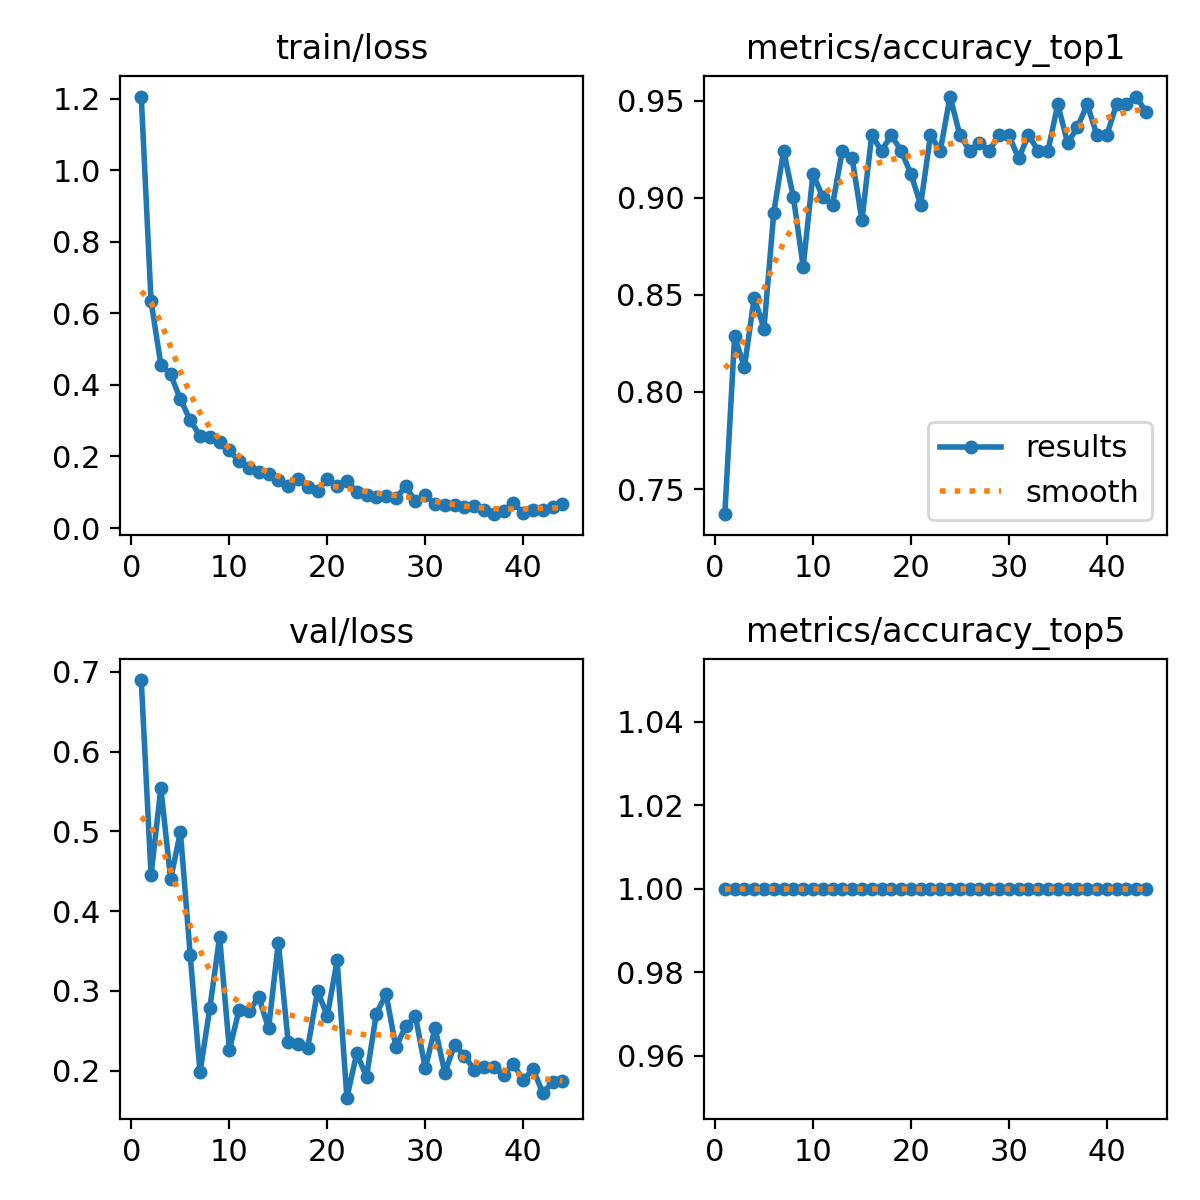

In [11]:
from IPython.display import Image as IPImage, display

results_png = save_dir / "results.png"
if results_png.exists():
    display(IPImage(str(results_png)))
else:
    print(f"results.png nu a fost găsit în {save_dir}")

---
## Experimente multiple B1, B2, B3

In [ ]:
CLS_EXPERIMENTS = [
    # (id,   model,           epochs, data_dir,                                               run_name)
    ("B1", "yolov8n-cls.pt",  50, str(REPO_ROOT / "datasets" / "parks_cls"),         "parks-cls-B1"),
    ("B2", "yolov8n-cls.pt",  50, str(REPO_ROOT / "datasets" / "trashnet_cls"),      "parks-cls-B2"),
    ("B3", "yolov8n-cls.pt",  80, str(REPO_ROOT / "datasets" / "mixed_cls"),         "parks-cls-B3"),
]

cls_exp_results = {}

for exp_id, base_model, num_epochs, data_dir, run_name in CLS_EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"EXPERIMENT {exp_id}: {base_model}  epochs={num_epochs}  data={Path(data_dir).name}")
    print('='*60)

    data_path = Path(data_dir)
    if not data_path.exists():
        print(f"[SKIP] Dataset inexistent: {data_path}"); continue

    train_images = list((data_path / "train").rglob("*")) if (data_path / "train").exists() else []
    train_images = [p for p in train_images if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}]
    if not train_images:
        print(f"[SKIP] Nicio imagine în train/: {data_path / 'train'}"); continue

    m = YOLO(base_model)
    m.train(
        data=data_dir, epochs=num_epochs, imgsz=IMGSZ,
        batch=BATCH, workers=WORKERS, patience=PATIENCE,
        name=run_name, seed=SEED, device=DEVICE,
    )
    vr = m.val(data=data_dir, split="val", imgsz=IMGSZ, batch=BATCH,
               device=DEVICE, workers=WORKERS)
    rd = getattr(vr, "results_dict", {})
    top1 = rd.get("metrics/accuracy_top1") or rd.get("top1") or rd.get("accuracy")

    save_dir_exp = Path(getattr(m, "trainer", type('o', (), {'save_dir': Path('runs')})()).save_dir)
    cls_exp_results[exp_id] = {
        "run_name" : run_name,
        "top1_acc" : float(top1) if top1 is not None else None,
        "best_pt"  : str(Path("runs/classify") / run_name / "weights" / "best.pt"),
    }

# Tabel sumar
print(f"\n\n{'ID':<4} {'Dataset':<20} {'Epochs':>6} {'Accuracy (val)':>15}")
print("-" * 50)
for exp_id, _, num_epochs, data_dir, _ in CLS_EXPERIMENTS:
    er  = cls_exp_results.get(exp_id, {})
    acc = er.get("top1_acc")
    print(f"{exp_id:<4} {Path(data_dir).name:<20} {num_epochs:>6} {f'{acc:.4f}' if acc is not None else '    —':>15}")



EXPERIMENT B1: yolov8n-cls.pt  epochs=50  data=parks_cls
New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\parks_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mod

RuntimeError: Dataset 'D://TrashDetectionSystem/datasets/parks_cls' error  D:\TrashDetectionSystem\datasets\parks_cls 'train:' no training images found